## Background
The marketing team of an e-commerce site has launched an email campaign. This site has email
addresses from all the users who created an account in the past.
They have chosen a random sample of users and emailed them. The email let the user know
about a new feature implemented on the site. From the marketing team perspective, a success
is if the user clicks on the link inside of the email. This link takes the user to the company site.
You are in charge of figuring out how the email campaign performed

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, roc_curve, classification_report,precision_score,recall_score

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2,f_classif

from sklearn.model_selection import train_test_split
import xgboost as xgb

import warnings
warnings.simplefilter('ignore')

# 1. Load Dataset

In [4]:
# import email_table.csv
df_original = pd.read_csv('email_table.csv')
df_original.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases
0,85120,short_email,personalized,2,Sunday,US,5
1,966622,long_email,personalized,12,Sunday,UK,2
2,777221,long_email,personalized,11,Wednesday,US,2
3,493711,short_email,generic,6,Monday,UK,1
4,106887,long_email,generic,14,Monday,US,6


In [5]:
df = df_original.copy()
df.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases
0,85120,short_email,personalized,2,Sunday,US,5
1,966622,long_email,personalized,12,Sunday,UK,2
2,777221,long_email,personalized,11,Wednesday,US,2
3,493711,short_email,generic,6,Monday,UK,1
4,106887,long_email,generic,14,Monday,US,6


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   email_id             100000 non-null  int64 
 1   email_text           100000 non-null  object
 2   email_version        100000 non-null  object
 3   hour                 100000 non-null  int64 
 4   weekday              100000 non-null  object
 5   user_country         100000 non-null  object
 6   user_past_purchases  100000 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 5.3+ MB


In [7]:
df.isnull().sum()

email_id               0
email_text             0
email_version          0
hour                   0
weekday                0
user_country           0
user_past_purchases    0
dtype: int64

In [8]:
df_email_opened = pd.read_csv('email_opened_table.csv')
df_email_opened

,email_id
0,284534
1,609056
2,220820
3,905936
4,164034
...,...
10340,990213
10341,918210
10342,200299
10343,211104


In [9]:
df_email_opened.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   email_id  10345 non-null  int64
dtypes: int64(1)
memory usage: 80.9 KB


In [10]:
df_email_opened.isnull().sum()

email_id    0
dtype: int64

In [11]:
df_link_clicked = pd.read_csv('link_clicked_table.csv')
df_link_clicked

,email_id
0,609056
1,870980
2,935124
3,158501
4,177561
...,...
2114,873162
2115,435454
2116,206772
2117,742967


In [12]:
df_link_clicked.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   email_id  2119 non-null   int64
dtypes: int64(1)
memory usage: 16.7 KB


In [13]:
df_link_clicked.isnull().sum()

email_id    0
dtype: int64

In [14]:
# check uniqueness of email_id in three tables
print('Number of unique email_id:')
print(f'    email_table.csv: {len(df['email_id'].unique())} / {len(df['email_id'])}')
print(f'    email_opened_table.csv: {len(df_email_opened['email_id'].unique())} / {len(df_email_opened['email_id'])}')
print(f'    link_clicked_table.csv: {len(df_link_clicked['email_id'].unique())} / {len(df_link_clicked['email_id'])}')

Number of unique email_id:
    email_table.csv: 100000 / 100000
    email_opened_table.csv: 10345 / 10345
    link_clicked_table.csv: 2119 / 2119


# 2. Data Processing

## 2.1 merge three tables into one


In [15]:
# 1. create a new column for df_email_opened
df_email_opened['opened'] = 1

# 2. create a new column for df_link_clicked
df_link_clicked['clicked'] = 1

# merge
df = pd.merge(left=df, right=df_email_opened, how='left', on='email_id')
df = pd.merge(left=df, right=df_link_clicked, how='left', on='email_id')

# fill NA with 0
df = df.fillna(value=0)

In [16]:
df.head()


,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases,opened,clicked
0,85120,short_email,personalized,2,Sunday,US,5,0.0,0.0
1,966622,long_email,personalized,12,Sunday,UK,2,1.0,1.0
2,777221,long_email,personalized,11,Wednesday,US,2,0.0,0.0
3,493711,short_email,generic,6,Monday,UK,1,0.0,0.0
4,106887,long_email,generic,14,Monday,US,6,0.0,0.0


In [17]:
# change 'opened' and 'clicked' columns to integer
df['opened'] = df['opened'].astype(int)
df['clicked'] = df['clicked'].astype(int)

df.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases,opened,clicked
0,85120,short_email,personalized,2,Sunday,US,5,0,0
1,966622,long_email,personalized,12,Sunday,UK,2,1,1
2,777221,long_email,personalized,11,Wednesday,US,2,0,0
3,493711,short_email,generic,6,Monday,UK,1,0,0
4,106887,long_email,generic,14,Monday,US,6,0,0


# Question 01
##### What percentage of users opened the email and what percentage clicked on the link within the email?

In [18]:
print(f"Percentage of opened the email: {df['opened'].sum()*100 / len(df)}%")
print(f"Percentage of clicked the link: {df['clicked'].sum()*100 / len(df)}%")

Percentage of opened the email: 10.345%
Percentage of clicked the link: 2.119%


# Question 02
#####  Did you find any interesting pattern on how the email campaign performed for different segments of users?

## Q2.1 EDA
EDA help us understand the data

In [19]:
# check if clicked column is balanced
clicked_dist = df['clicked'].value_counts(normalize=True)
clicked_dist

clicked
0    0.97881
1    0.02119
Name: proportion, dtype: float64

As we can see above, it is **highly imbalanced**

## Chi-Square test

Chi-Square helps us find which feature have great impact on click rate

In [23]:
from scipy.stats import chi2_contingency

df_ch2 = df.copy()

# Group past purchases into categories
df_ch2['purchase_group'] = pd.cut(
    df_ch2['user_past_purchases'],
    bins=[-1, 0, 2, 5, 10, float('inf')],
    labels=['0', '1-2', '3-5', '6-10', '11+']
)

categorical_columns = [
    'email_text',
    'email_version',
    'hour',
    'weekday',
    'user_country',
    'purchase_group'
]

results = []

for column in categorical_columns:

    # Convert categorical dtype to object so "Missing" can be added
    feature = df_ch2[column].astype(object).fillna('Missing')

    contingency_table = pd.crosstab(
        feature,
        df_ch2['clicked']
    )
    print(contingency_table)
    print("=================")

    chi2_value, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    results.append({
        'feature': column,
        'chi2_value': chi2_value,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'minimum_expected_count': expected.min()
    })

clicked          0     1
email_text              
long_email   49344   932
short_email  48537  1187
clicked            0     1
email_version             
generic        49449   760
personalized   48432  1359
clicked     0    1
hour              
1        2654   49
2        3616   60
3        4520   90
4        5531   91
5        6433  118
6        7337  128
7        8054  150
8        8239  159
9        8309  220
10       7949  231
11       7280  203
12       6341  167
13       5470  111
14       4485   95
15       3406   87
16       2695   64
17       1858   35
18       1398   23
19        890   15
20        648    8
21        362    3
22        200    4
23        139    6
24         67    2
clicked        0    1
weekday              
Friday     13978  199
Monday     14034  329
Saturday   14309  260
Sunday     14146  241
Thursday   13928  349
Tuesday    13791  352
Wednesday  13695  389
clicked           0     1
user_country             
ES             9884    83
FR             9915   

In [24]:
chi2_results = (
    pd.DataFrame(results)
    .sort_values('p_value')
    .reset_index(drop=True)
)

chi2_results

,feature,chi2_value,p_value,degrees_of_freedom,minimum_expected_count
0,purchase_group,1061.879962,1.385347e-228,4,81.64507
1,user_country,204.082662,5.533103e-44,3,211.20073
2,email_version,177.562629,1.650505e-40,1,1055.07129
3,weekday,103.230664,5.310038e-20,6,298.43996
4,hour,89.882172,7.439809e-10,23,1.46211
5,email_text,34.037432,5.406197e-09,1,1053.65156


As we can see above,
* I used a chi-square test to check whether each feature is associated with whether a user clicks. Since all p-values are far below 0.05, all six features show a statistically significant relationship with clicking.

* Purchase group shows the strongest signal, followed by country and email version. Weekday and email length are also significant. Hour appears significant too, but its minimum expected count is below 5, so I would treat that result cautiously and consider grouping hours into broader time periods.

* I would also clarify that this shows association, not causation, and I would use effect size and click-rate comparisons before ranking practical importance.


## Q2.2 Visualization

### I. Visualization of user_past_purchases
*  how many items in the past were bought by the user receiving the email

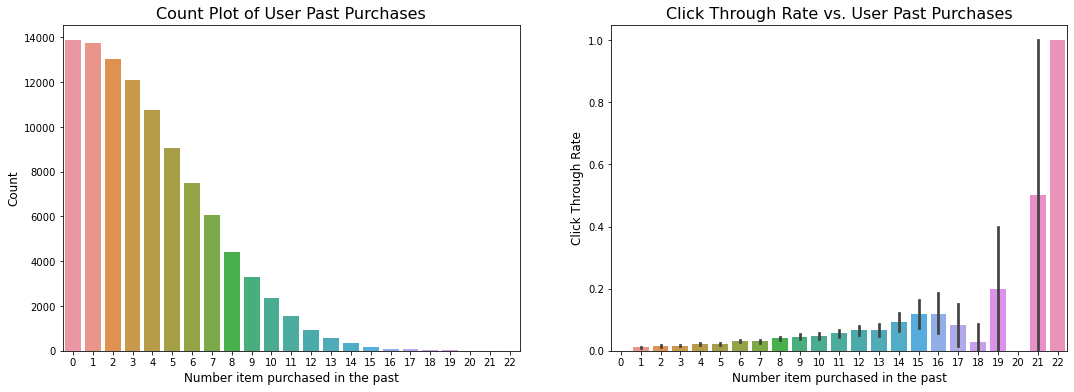

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='user_past_purchases',data=df, ax=ax[0])
ax[0].set_xlabel('Number item purchased in the past', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of User Past Purchases', fontsize=16)


sns.barplot(x='user_past_purchases', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Number item purchased in the past', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. User Past Purchases', fontsize=16)
plt.show()

In the above plots,
* the number of purchases is **positively correlated** with the click-through rate. Especially when the purchase is more than 20 times, the click-through rate increases significantly
* When the number of purchases are 17 and 18, the click-through rate decreased. Maybe because there are not enought sample size, so our company only captured this gorup of users who are unwilling to click. But we need further investigation 
* There is no any click when the number of purchases is 20, and it is very unusual. Maybe there are some technical issues prevent customers from clicking, or because the numbers of this group users are too small, so our company just happened not to send any emails to this group of users

### II. Visualization of email_version
*   Some emails were "personalized" (i.e. they had the name of the user receiving the email in the incipit, such as "Hi John,"), while some emails were "generic" (the incipit was just "Hi,").

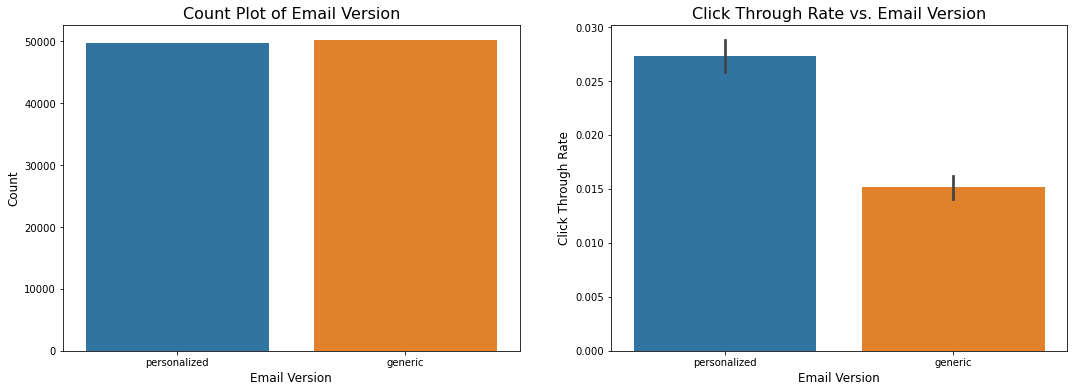

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='email_version',data=df, ax=ax[0])
ax[0].set_xlabel('Email Version', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Email Version', fontsize=16)


sns.barplot(x='email_version', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Email Version', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Email Version', fontsize=16)
plt.show()

In the above plots,
* It is clear that **personalized emails** can bring higher click-through rate

### III. Visualization of user_country
*   The country where the user receiving the email was based. It comes from the user ip address when user created the account.

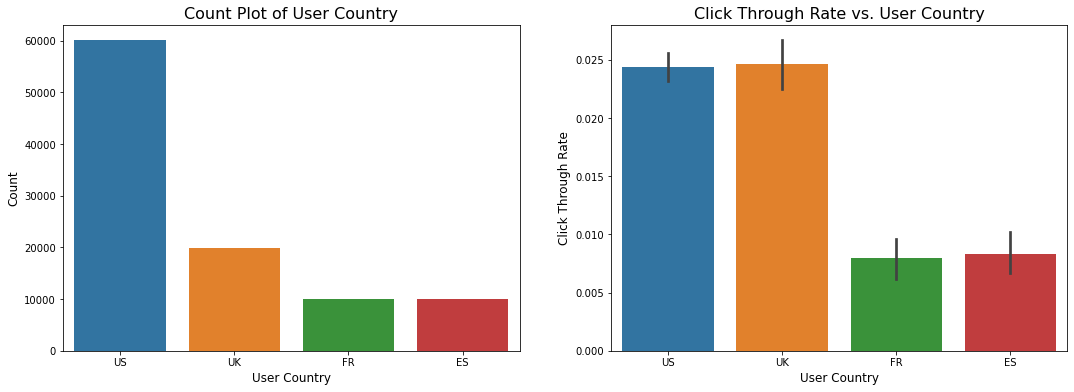

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='user_country',data=df, ax=ax[0])
ax[0].set_xlabel('User Country', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of User Country', fontsize=16)


sns.barplot(x='user_country', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('User Country', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. User Country', fontsize=16)
plt.show()

In the above plots,
* **US** and **UK** users have the highest click-through rate

### IV. Visualization of weekday
*   The day when the email was sent.

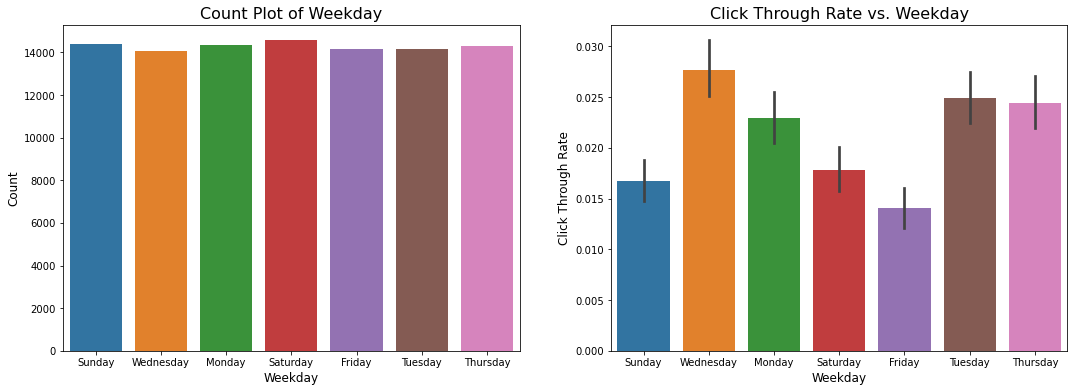

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='weekday',data=df, ax=ax[0])
ax[0].set_xlabel('Weekday', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Weekday', fontsize=16)


sns.barplot(x='weekday', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Weekday', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Weekday', fontsize=16)
plt.show()

In the above plots,
* **Wednesday** have the highest click-through rate
* The click-through rate of **Tuesday** and **Thursday** are also very high

### V. Visualization of hour
*   The user local time when the email was sent.

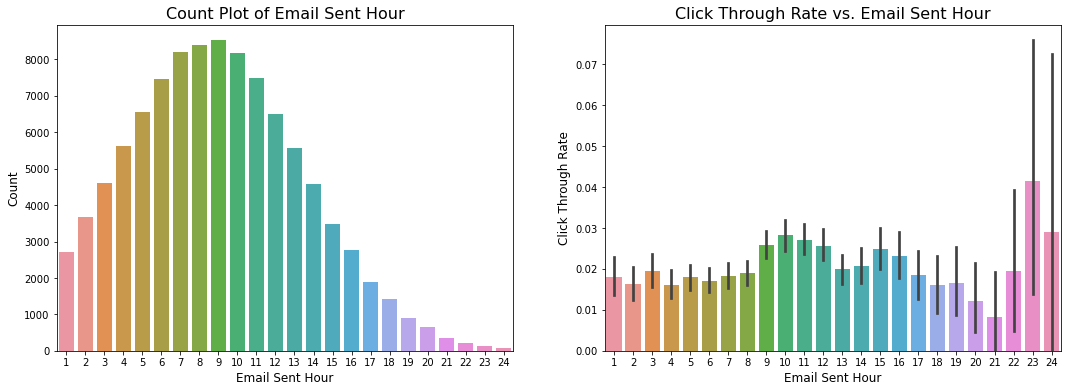

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='hour',data=df, ax=ax[0])
ax[0].set_xlabel('Email Sent Hour', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Email Sent Hour', fontsize=16)


sns.barplot(x='hour', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Email Sent Hour', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Email Sent Hour', fontsize=16)
plt.show()

In the above plots,
* When the emails are sent between **23 to 24 o'clock**, our company receives the highest click-through rate 

### VI. Visualization of email_text
*   There are two versions of the email: one has "long text" (i.e. has 4 paragraphs) and one has "short text" (just 2 paragraphs)

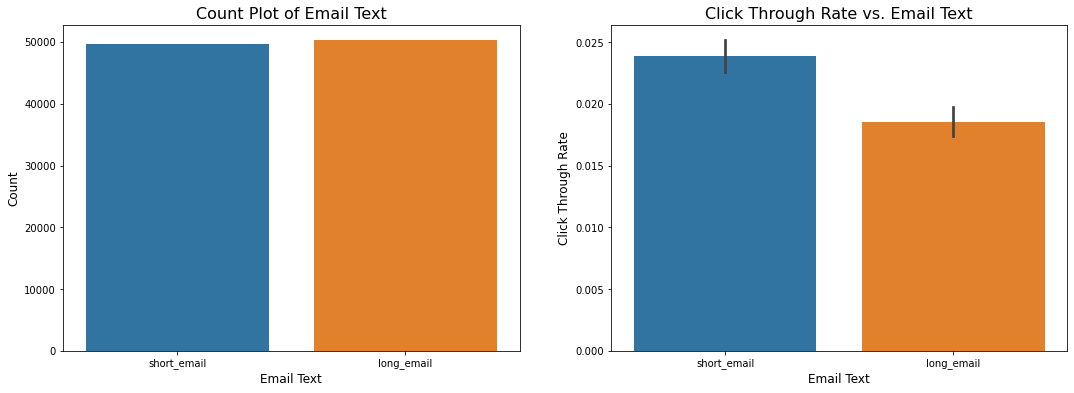

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='email_text',data=df, ax=ax[0])
ax[0].set_xlabel('Email Text', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Email Text', fontsize=16)


sns.barplot(x='email_text', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Email Text', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Email Text', fontsize=16)
plt.show()

In the above plots,
* It is clear that **"short text" email** can bring higher click-through rate

# Question 03
* Based on all the information you have about the emails that were sent, can you build a model to optimize in future email campaigns to maximize the probability of users clicking on the link inside the email?


## ML Model
We will use XGBoost.

Below is a cleaner end-to-end version that keeps the useful ideas from your original code:

Separate training, validation, and test sets
One-hot encoding with pd.get_dummies()
Stratified splitting
Validation-based early stopping
Threshold selection on validation data only
Final test evaluation
ROC-AUC, average precision, confusion matrix, and classification report
Gain-based feature importance

We use XGBClassifier here instead of manually creating DMatrix objects. Current XGBoost estimators automatically use best_iteration for predict() and predict_proba() after early stopping, so ntree_limit is no longer needed.

## 3.1 XGBoost Model code

Use **manual `StratifiedKFold` cross-validation** rather than plain `cross_val_score()` or preprocessing the whole training set once.

This lets us:

- Fit missing-value handling and one-hot encoding separately inside every fold.
- Use early stopping independently in every fold.
- Generate out-of-fold predictions for threshold selection.
- Keep one untouched test set for the final evaluation.

`StratifiedKFold` preserves approximately the same click/non-click proportion in every fold. Each development-set row is used once for validation and in the remaining folds for training

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    roc_auc_score
)

### 1. Configuration and feature selection
`email_id` is excluded because it is an identifier. `opened` is also excluded because it happens after sending the email and would cause leakage when the objective is to predict clicks before sending.
****

In [ ]:
# ============================================================
# Configuration
# ============================================================

RANDOM_STATE = 11
N_SPLITS = 5

TARGET_COLUMN = "clicked"

FEATURE_COLUMNS = [
    "email_text",
    "email_version",
    "hour",
    "weekday",
    "user_country",
    "user_past_purchases"
]

CATEGORICAL_COLUMNS = [
    "email_text",
    "email_version",
    "hour",
    "weekday",
    "user_country"
]

NUMERIC_COLUMNS = [
    "user_past_purchases"
]

# Maximum number of trees allowed in each CV fold.
# Early stopping will usually stop before this.
MAX_BOOST_ROUNDS = 3000
EARLY_STOPPING_ROUNDS = 50

# Used later when selecting the classification threshold.
MINIMUM_RECALL = 0.60

# Compare True and False during experimentation.
USE_CLASS_WEIGHT = True

### 2. Prepare the raw data

Only rule-based cleaning is done before splitting. Data-dependent operations such as median imputation and category learning happen inside each fold.

In [ ]:
# ============================================================
# Validate and prepare raw data
# ============================================================

required_columns = set(FEATURE_COLUMNS + [TARGET_COLUMN])

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )


model_data = (
    df[FEATURE_COLUMNS + [TARGET_COLUMN]]
    .copy()
    .dropna(subset=[TARGET_COLUMN])
)

X = model_data[FEATURE_COLUMNS].copy()
y = model_data[TARGET_COLUMN].astype(int).copy()


if not set(y.unique()).issubset({0, 1}):
    raise ValueError(
        "The target column must contain only 0 and 1."
    )


# Fixed categorical cleaning is safe before splitting.
# Convert hour to a categorical string as well.
for column in CATEGORICAL_COLUMNS:
    X[column] = (
        X[column]
        .astype("string")
        .fillna("Missing")
    )


print("Dataset shape:", model_data.shape)
print("Click rate:", round(y.mean(), 4))

print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (100000, 7)
Click rate: 0.0212

Target distribution:
clicked
0    97881
1     2119
Name: count, dtype: int64


### 3. Reserve an untouched test set

The five-fold cross-validation is run only on the development set. The test set remains untouched until all model and threshold decisions are complete.

In [ ]:
# ============================================================
# Development/test split
#
# 80%: five-fold cross-validation and model decisions
# 20%: final test evaluation
# ============================================================

X_development, X_test_raw, y_development, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
)


print("\nDevelopment shape:", X_development.shape)
print("Test shape:", X_test_raw.shape)

print("\nDevelopment click rate:", round(y_development.mean(), 4))
print("Test click rate:", round(y_test.mean(), 4))


# Five-fold stratification requires enough positive examples.
smallest_class_count = y_development.value_counts().min()

if smallest_class_count < N_SPLITS:
    raise ValueError(
        f"The smallest target class has only "
        f"{smallest_class_count} examples, which is fewer "
        f"than N_SPLITS={N_SPLITS}."
    )


Development shape: (80000, 6)
Test shape: (20000, 6)

Development click rate: 0.0212
Test click rate: 0.0212


### 4. Define preprocessing

The preprocessor will be cloned and fitted separately inside each cross-validation fold.

`handle_unknown="ignore"` means a category appearing in validation, test, or future production data but not in training will not cause an error.

For older scikit-learn versions that do not recognize `sparse_output`, replace:

```
sparse_output=True
```

with:

```
sparse=True
```

In [22]:
# ============================================================
# Preprocessing definition
# ============================================================

categorical_preprocessor = Pipeline(
    steps=[
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32
            )
        )
    ]
)


numeric_preprocessor = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


base_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_preprocessor,
            CATEGORICAL_COLUMNS
        ),
        (
            "numeric",
            numeric_preprocessor,
            NUMERIC_COLUMNS
        )
    ],
    remainder="drop"
)

## 5. Calculate class weight

We use the same class weight across all folds so that fold predictions remain more comparable.

In [23]:
# ============================================================
# Class imbalance weight
# ============================================================

number_of_negatives = int((y_development == 0).sum())
number_of_positives = int((y_development == 1).sum())

if number_of_positives == 0:
    raise ValueError(
        "The development set contains no positive examples."
    )


class_ratio = (
    number_of_negatives / number_of_positives
)

scale_pos_weight = (
    class_ratio
    if USE_CLASS_WEIGHT
    else 1.0
)


print("\nNegative examples:", number_of_negatives)
print("Positive examples:", number_of_positives)
print("Negative/positive ratio:", round(class_ratio, 3))
print("scale_pos_weight:", round(scale_pos_weight, 3))


Negative examples: 78305
Positive examples: 1695
Negative/positive ratio: 46.198
scale_pos_weight: 46.198


### 6. XGBoost model factory

In [24]:
# ============================================================
# Model factory
# ============================================================

def create_xgboost_model(
    n_estimators,
    early_stopping_rounds=None
):
    """
    Create a fresh XGBoost classifier.

    early_stopping_rounds is used during CV folds but omitted
    when training the final model on all development data.
    """

    parameters = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",

        "n_estimators": n_estimators,
        "learning_rate": 0.05,

        "max_depth": 4,
        "min_child_weight": 2,
        "gamma": 0,

        "subsample": 0.80,
        "colsample_bytree": 0.80,

        "reg_alpha": 0.0,
        "reg_lambda": 1.0,

        "scale_pos_weight": scale_pos_weight,

        "tree_method": "hist",
        "importance_type": "gain",

        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    if early_stopping_rounds is not None:
        parameters["early_stopping_rounds"] = (
            early_stopping_rounds
        )

    return xgb.XGBClassifier(**parameters)

### 7. Run five-fold cross-validation

Each fold follows this sequence:

```
Fit preprocessing on fold training data
        ↓
Transform fold training and validation data
        ↓
Train XGBoost with early stopping
        ↓
Predict the held-out fold
```

Early stopping monitors each fold’s validation score and stops when it fails to improve for the configured number of rounds

In [25]:
# ============================================================
# Five-fold stratified cross-validation
# ============================================================

cross_validator = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Every development row will receive one prediction from a
# model that did not train on that row.
out_of_fold_probabilities = np.zeros(
    len(X_development),
    dtype=float
)

fold_results = []
fold_best_rounds = []


for fold_number, (train_indices, valid_indices) in enumerate(
    cross_validator.split(
        X_development,
        y_development
    ),
    start=1
):
    print("\n" + "=" * 60)
    print(f"Fold {fold_number}/{N_SPLITS}")
    print("=" * 60)

    # --------------------------------------------
    # Fold-specific raw datasets
    # --------------------------------------------

    X_fold_train_raw = X_development.iloc[
        train_indices
    ]

    X_fold_valid_raw = X_development.iloc[
        valid_indices
    ]

    y_fold_train = y_development.iloc[
        train_indices
    ]

    y_fold_valid = y_development.iloc[
        valid_indices
    ]


    # --------------------------------------------
    # Fit preprocessing on fold training only
    # --------------------------------------------

    fold_preprocessor = clone(base_preprocessor)

    X_fold_train = fold_preprocessor.fit_transform(
        X_fold_train_raw
    )

    X_fold_valid = fold_preprocessor.transform(
        X_fold_valid_raw
    )


    # --------------------------------------------
    # Train fold model with early stopping
    # --------------------------------------------

    fold_model = create_xgboost_model(
        n_estimators=MAX_BOOST_ROUNDS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train,

        # This fold's validation set controls early stopping.
        eval_set=[
            (X_fold_valid, y_fold_valid)
        ],

        verbose=False
    )


    # XGBoost's current estimator interface uses the best
    # iteration for predictions after early stopping.
    fold_probabilities = fold_model.predict_proba(
        X_fold_valid
    )[:, 1]


    # Save predictions in their original development-set rows.
    out_of_fold_probabilities[
        valid_indices
    ] = fold_probabilities


    # --------------------------------------------
    # Fold metrics
    # --------------------------------------------

    fold_roc_auc = roc_auc_score(
        y_fold_valid,
        fold_probabilities
    )

    fold_average_precision = average_precision_score(
        y_fold_valid,
        fold_probabilities
    )

    best_number_of_trees = (
        int(fold_model.best_iteration) + 1
    )

    fold_best_rounds.append(
        best_number_of_trees
    )

    fold_results.append({
        "fold": fold_number,
        "training_rows": len(train_indices),
        "validation_rows": len(valid_indices),
        "validation_click_rate": y_fold_valid.mean(),
        "roc_auc": fold_roc_auc,
        "average_precision": fold_average_precision,
        "best_number_of_trees": best_number_of_trees
    })


    print(
        "Validation click rate:",
        round(y_fold_valid.mean(), 4)
    )

    print(
        "ROC-AUC:",
        round(fold_roc_auc, 4)
    )

    print(
        "Average precision:",
        round(fold_average_precision, 4)
    )

    print(
        "Best number of trees:",
        best_number_of_trees
    )


Fold 1/5
Validation click rate: 0.0212
ROC-AUC: 0.74
Average precision: 0.0592
Best number of trees: 29

Fold 2/5
Validation click rate: 0.0212
ROC-AUC: 0.7434
Average precision: 0.0641
Best number of trees: 105

Fold 3/5
Validation click rate: 0.0212
ROC-AUC: 0.7367
Average precision: 0.0657
Best number of trees: 68

Fold 4/5
Validation click rate: 0.0212
ROC-AUC: 0.7314
Average precision: 0.0557
Best number of trees: 39

Fold 5/5
Validation click rate: 0.0212
ROC-AUC: 0.7521
Average precision: 0.0711
Best number of trees: 43


### 8. Summarize cross-validation results

In [26]:
# ============================================================
# Cross-validation summary
# ============================================================

cv_results = pd.DataFrame(fold_results)

print("\nCross-validation results:")
print(cv_results)


print("\nMean and standard deviation:")

print(
    "ROC-AUC:",
    round(cv_results["roc_auc"].mean(), 4),
    "+/-",
    round(cv_results["roc_auc"].std(), 4)
)

print(
    "Average precision:",
    round(
        cv_results["average_precision"].mean(),
        4
    ),
    "+/-",
    round(
        cv_results["average_precision"].std(),
        4
    )
)

print(
    "Best tree count:",
    round(
        cv_results["best_number_of_trees"].mean(),
        1
    ),
    "+/-",
    round(
        cv_results["best_number_of_trees"].std(),
        1
    )
)


Cross-validation results:
   fold  training_rows  validation_rows  validation_click_rate   roc_auc  \
0     1          64000            16000               0.021188  0.740046   
1     2          64000            16000               0.021188  0.743444   
2     3          64000            16000               0.021188  0.736707   
3     4          64000            16000               0.021188  0.731351   
4     5          64000            16000               0.021188  0.752086   

   average_precision  best_number_of_trees  
0           0.059212                    29  
1           0.064130                   105  
2           0.065663                    68  
3           0.055680                    39  
4           0.071125                    43  

Mean and standard deviation:
ROC-AUC: 0.7407 +/- 0.0078
Average precision: 0.0632 +/- 0.006
Best tree count: 56.8 +/- 30.5


#### Also calculate metrics from all combined out-of-fold predictions:
Average precision summarizes the precision-recall relationship across thresholds, while ROC-AUC evaluates ranking across false-positive and true-positive rates.

In [27]:
# ============================================================
# Overall out-of-fold metrics
# ============================================================

oof_roc_auc = roc_auc_score(
    y_development,
    out_of_fold_probabilities
)

oof_average_precision = average_precision_score(
    y_development,
    out_of_fold_probabilities
)

print("\nOverall out-of-fold results:")
print("ROC-AUC:", round(oof_roc_auc, 4))
print(
    "Average precision:",
    round(oof_average_precision, 4)
)
print(
    "Baseline click rate:",
    round(y_development.mean(), 4)
)


Overall out-of-fold results:
ROC-AUC: 0.7384
Average precision: 0.0586
Baseline click rate: 0.0212


### 9. Select a threshold using out-of-fold predictions

The out-of-fold predictions are appropriate for threshold selection because every prediction was generated by a model that did not train on that row.

In [28]:
# ============================================================
# Threshold selection
# ============================================================

def choose_threshold_for_minimum_recall(
    y_true,
    probabilities,
    minimum_recall=0.60
):
    """
    Find thresholds achieving at least the required recall,
    then select the one with the highest precision.
    """

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities
        )
    )

    # The final precision and recall values do not have
    # a corresponding threshold.
    precision_for_thresholds = precision[:-1]
    recall_for_thresholds = recall[:-1]

    eligible_indices = np.flatnonzero(
        recall_for_thresholds >= minimum_recall
    )

    if len(eligible_indices) == 0:
        raise ValueError(
            f"No threshold achieved recall >= "
            f"{minimum_recall:.2%}."
        )

    eligible_precision = precision_for_thresholds[
        eligible_indices
    ]

    best_position = np.argmax(
        eligible_precision
    )

    best_index = eligible_indices[
        best_position
    ]

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(
            precision_for_thresholds[best_index]
        ),
        "recall": float(
            recall_for_thresholds[best_index]
        )
    }


threshold_result = (
    choose_threshold_for_minimum_recall(
        y_true=y_development,
        probabilities=out_of_fold_probabilities,
        minimum_recall=MINIMUM_RECALL
    )
)

selected_threshold = threshold_result["threshold"]


print("\nSelected threshold from OOF predictions:")
print("Threshold:", round(selected_threshold, 6))
print(
    "OOF precision:",
    round(threshold_result["precision"], 4)
)
print(
    "OOF recall:",
    round(threshold_result["recall"], 4)
)


Selected threshold from OOF predictions:
Threshold: 0.550027
OOF precision: 0.0458
OOF recall: 0.6012


### 10. Select the final number of trees

Each fold may choose a different best number of trees. A practical choice is the median of the fold results because the median is less affected by one unusually large or small fold value.

For example:

```
Fold tree counts: [184, 216, 197, 253, 205]
Final number of trees: 205
```

In [29]:
# ============================================================
# Select final number of trees
# ============================================================

final_number_of_trees = max(
    1,
    int(np.median(fold_best_rounds))
)

print(
    "\nFinal number of trees:",
    final_number_of_trees
)

print(
    "Fold tree counts:",
    fold_best_rounds
)


Final number of trees: 43
Fold tree counts: [29, 105, 68, 39, 43]


### 11. Train the final model

Now fit preprocessing on all development data and train one final model using the cross-validation-selected number of trees.

We no longer use early stopping here because the entire development set is being used for training.

In [30]:
# ============================================================
# Final preprocessing
# ============================================================

final_preprocessor = clone(
    base_preprocessor
)

X_development_transformed = (
    final_preprocessor.fit_transform(
        X_development
    )
)

X_test_transformed = (
    final_preprocessor.transform(
        X_test_raw
    )
)


print(
    "\nFinal transformed development shape:",
    X_development_transformed.shape
)

print(
    "Final transformed test shape:",
    X_test_transformed.shape
)


Final transformed development shape: (80000, 40)
Final transformed test shape: (20000, 40)


In [31]:
# ============================================================
# Train final model on all development data
# ============================================================

final_model = create_xgboost_model(
    n_estimators=final_number_of_trees,
    early_stopping_rounds=None
)

final_model.fit(
    X_development_transformed,
    y_development,
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

### 12. Evaluate the untouched test set

In [32]:
# ============================================================
# Evaluation function
# ============================================================

def evaluate_predictions(
    dataset_name,
    y_true,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    average_precision = average_precision_score(
        y_true,
        probabilities
    )

    print("\n" + "=" * 60)
    print(dataset_name)
    print("=" * 60)

    print("Threshold:", round(threshold, 6))
    print(
        "Actual click rate:",
        round(y_true.mean(), 4)
    )
    print(
        "Predicted click rate:",
        round(predictions.mean(), 4)
    )
    print("ROC-AUC:", round(roc_auc, 4))
    print(
        "Average precision:",
        round(average_precision, 4)
    )

    print("\nConfusion matrix:")
    print(
        confusion_matrix(
            y_true,
            predictions
        )
    )

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            predictions,
            target_names=[
                "not_clicked",
                "clicked"
            ],
            digits=4,
            zero_division=0
        )
    )

    return {
        "probabilities": probabilities,
        "predictions": predictions,
        "roc_auc": roc_auc,
        "average_precision": average_precision
    }

In [33]:
# ============================================================
# Final test predictions
# ============================================================

test_probabilities = final_model.predict_proba(
    X_test_transformed
)[:, 1]


test_results = evaluate_predictions(
    dataset_name="Final test results",
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=selected_threshold
)


Final test results
Threshold: 0.550027
Actual click rate: 0.0212
Predicted click rate: 0.2638
ROC-AUC: 0.7317
Average precision: 0.0517

Confusion matrix:
[[14539  5037]
 [  184   240]]

Classification report:
              precision    recall  f1-score   support

 not_clicked     0.9875    0.7427    0.8478     19576
     clicked     0.0455    0.5660    0.0842       424

    accuracy                         0.7389     20000
   macro avg     0.5165    0.6544    0.4660     20000
weighted avg     0.9675    0.7389    0.8316     20000



### 13. Plot ROC and precision-recall curves

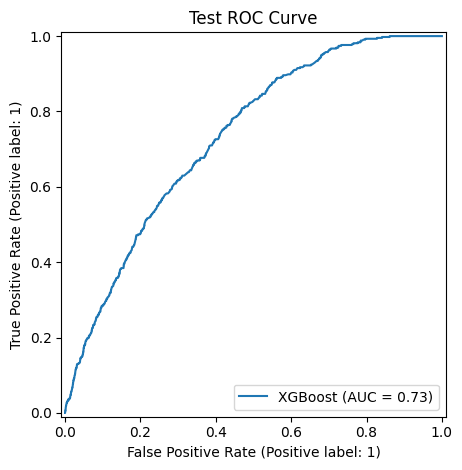

In [34]:
# ============================================================
# Test ROC curve
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="XGBoost"
)

plt.title("Test ROC Curve")
plt.tight_layout()
plt.show()

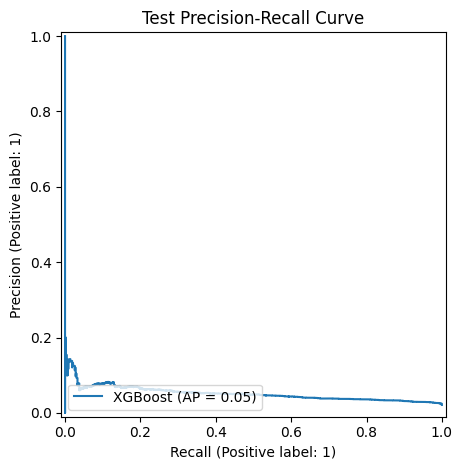

In [35]:
# ============================================================
# Test precision-recall curve
# ============================================================

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="XGBoost"
)

plt.title("Test Precision-Recall Curve")
plt.tight_layout()
plt.show()

### 14. Feature importance

In [36]:

# ============================================================
# Feature importance
# ============================================================

feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nTop 20 features:")
print(feature_importance.head(20))


Top 20 features:
                                    feature  importance
0              numeric__user_past_purchases    0.240069
1        categorical__email_version_generic    0.069734
2              categorical__user_country_ES    0.063507
3              categorical__user_country_FR    0.061291
4   categorical__email_version_personalized    0.056781
5       categorical__email_text_short_email    0.034214
6        categorical__email_text_long_email    0.032676
7             categorical__weekday_Thursday    0.026756
8            categorical__weekday_Wednesday    0.025495
9               categorical__weekday_Sunday    0.024709
10             categorical__user_country_UK    0.024271
11              categorical__weekday_Friday    0.022823
12                      categorical__hour_2    0.022454
13                      categorical__hour_3    0.021439
14                     categorical__hour_12    0.020048
15                      categorical__hour_4    0.019405
16                     categor

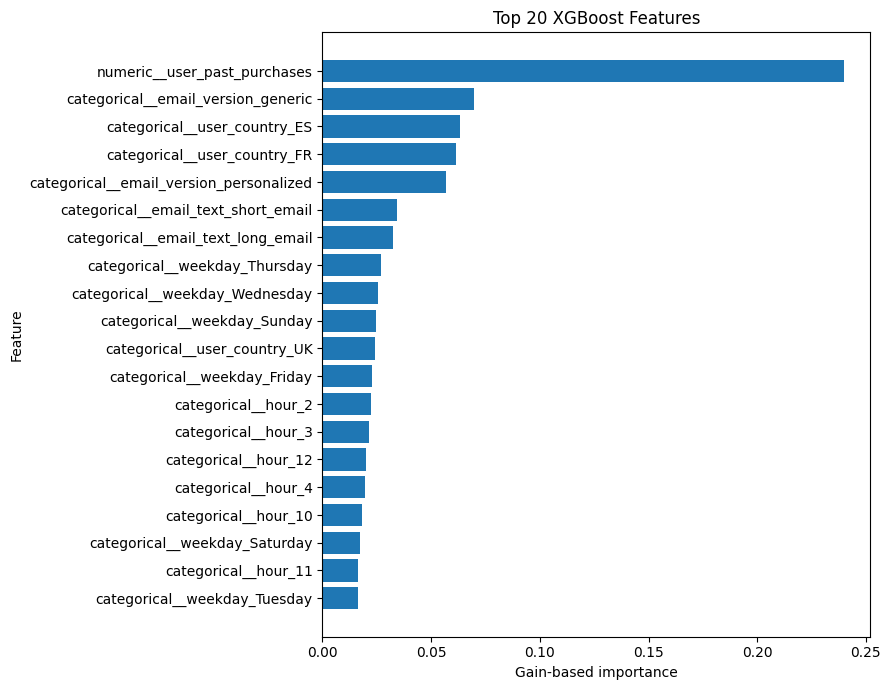

In [37]:
top_features = (
    feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Gain-based importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

# Summary01 - How this differs from the previous train/validation/test version

The previous version used:

```
70% training
15% validation
15% test
```

This version uses:

```
80% development
    ├── Fold 1 validation
    ├── Fold 2 validation
    ├── Fold 3 validation
    ├── Fold 4 validation
    └── Fold 5 validation

20% untouched final test
```

The advantages are:

- Every development row participates in training in four folds.
- Every development row receives one held-out prediction.
- Model performance is averaged across five different splits.
- Threshold selection uses all out-of-fold predictions rather than one validation split.
- The final test data remains completely separate.

The main number to report from cross-validation would look like:

> “Using five-fold stratified cross-validation, the model achieved a mean ROC-AUC of 0.74 with a standard deviation of 0.01 and a mean average precision of 0.06. I then selected the classification threshold from out-of-fold predictions, retrained the model on the full development set, and evaluated it once on the untouched test set.”
> 

XGBoost also provides native `xgb.cv()` with stratification and early stopping, but the manual loop is preferable here because preprocessing is learned independently within each fold and it produces row-level out-of-fold probabilities for threshold selection. Native `xgb.cv()` does support cross-validation early stopping based on the average fold metric

# Summary02 - Simple rule to measure which model is better
To cut through the noise of all these numbers, you only need to focus on **one global metric** to pick the best model, and **one operational metric** to run your business.

Because your click data is heavily imbalanced, you can completely ignore Accuracy, ROC-AUC, and all Weighted Averages.

Here is the simple, two-step rule to always know which model is better:

#### Rule 1: Use "Average Precision" (AP) to pick the winning model

When comparing Model A vs. Model B, look **only** at Average Precision (or PR-AUC).

- **The Rule**: The model with the higher Average Precision is the mathematically superior model. Period.
- **Why**: It evaluates the model across *all* possibilities. It proves which model is actually smarter at ranking potential clickers at the top, completely independent of whatever temporary threshold you chose.

#### Rule 2: Use the "Clicked F1-Score" to pick the best setting

Once you have picked the winning model using Rule 1, look at the **`clicked` row** in your classification report to find the best operational setting (threshold).

- **The Rule**: Look exclusively at the **F1-score for the `clicked` class**. The threshold that maximizes this specific number gives you the best real-world balance between catching clickers and avoiding false alarms.
- **Why**: The F1-score mathematically crashes if your precision is terrible or if your recall is terrible. It forces a healthy compromise.

---

#### 💡 Cheat Sheet Summary

Whenever you train new models, put them through this simple filter:

1. **Which model is inherently better?** $\rightarrow$ Look at **Average Precision (AP)**.
2. **Which target group matters?** $\rightarrow$ Look only at the **`clicked` row** metrics.
3. **Is the balance right?** $\rightarrow$ Look at the **`clicked` F1-score**.
4. **What can I ignore?** $\rightarrow$ Ignore **Accuracy**, **ROC-AUC**, and **Weighted Averages**.

Using this rule for your data, your **old model** was the better model (higher AP), but your **new model setup** accidentally had a better F1-score simply because it used a tighter threshold.


# Question 04
* By how much do you think your model would improve click through rate ( defined as # of users who click on the link / total users who received the email). How would you test that?

In [47]:
# Convert probabilities to predicted classes
test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

# Current CTR across all users
original_ctr = y_test.mean()

# CTR among users selected by the model
model_ctr = y_test[test_predictions == 1].mean()

# Improvement
absolute_improvement = model_ctr - original_ctr
relative_improvement = model_ctr / original_ctr - 1

print(f"Original CTR: {original_ctr:.2%}")
print(f"Model-targeted CTR: {model_ctr:.2%}")
print(f"Absolute improvement: {absolute_improvement:.2%}")
print(f"Relative improvement: {relative_improvement:.1%}")

Original CTR: 2.12%
Model-targeted CTR: 4.55%
Absolute improvement: 2.43%
Relative improvement: 114.5%


* Answer: The new click through rate is 4.55%. Compare with the old click through rate (2.12%) , the new click through rate is creased **2.43%**

##### How would you test that?

To test my conclusion, we need to perform a A/B test:

1. Randomly assign users to two groups, Control group and Experiment group.
2. In Control group, still use the old email-campaign strategy, i.e., just send emails to all users in Control group.
3. In Experiment group, use my model to predict whether the user will click the link or not. and only send emails to those users whose predictive result is positive.
4. Then we preform a one-tail unpaired t-test to test whether Experiement group's click through rate is higher than Control group's click through rate.